## Exercise: KNN and Naive Bayes

#### In this exercise, we train a k-nearest neighbours model and experiment with various parameters.

### Learning Objectives
#### By the end of this notebook, you should be able to:
#### - Train a k-nearest neighbours model.
#### - Compare KNN models trained with different parameters

### Overview
#### K-nearest neighbours (KNN) is a simple, instance-based learning algorithm in which an observation's classification is determined by the majority vote of its neighbours. In this exercise, we will explore the KNN model's sensitivity to the choice of the number of neighbours (K) and the type of distance metric used.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

### Load and prepare the dataset

In [3]:
# load the dataset
X, y = load_breast_cancer(return_X_y=True)

In [4]:
# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Exercise 1

#### Let's experiment with different values of k to understand how it affects the accuracy and generalisation of the model.

#### Use a for loop to train different k-nearest neighbours models, each with a differnt number of neighbours as follows: `1, 3, 4, 5, 9`. Evaluate each model's performance on the test set and pring its accuracy score

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

test_accuracies = []

k_values = range(1, 20)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)
    test_accuracy = knn.score(X_test_scaled, y_test)

    test_accuracies.append(test_accuracy)

    print(f"k = {k}, Test accuracy = {test_accuracy:.4f}")

k = 1, Test accuracy = 0.9211
k = 2, Test accuracy = 0.9386
k = 3, Test accuracy = 0.9561
k = 4, Test accuracy = 0.9561
k = 5, Test accuracy = 0.9561
k = 6, Test accuracy = 0.9561
k = 7, Test accuracy = 0.9561
k = 8, Test accuracy = 0.9649
k = 9, Test accuracy = 0.9649
k = 10, Test accuracy = 0.9649
k = 11, Test accuracy = 0.9561
k = 12, Test accuracy = 0.9561
k = 13, Test accuracy = 0.9561
k = 14, Test accuracy = 0.9561
k = 15, Test accuracy = 0.9561
k = 16, Test accuracy = 0.9561
k = 17, Test accuracy = 0.9474
k = 18, Test accuracy = 0.9474
k = 19, Test accuracy = 0.9474


In [22]:
best_idx = test_accuracies.index(
    max(test_accuracies)
)

best_k = k_values[best_idx]

best_k

8

### Exercise 2

#### Let's also compare the impact that different distance metrics will have on the accuracy of the KNN model. Again, use a for loop to train different k-nearest neighbours models, each with a different distance metric as follows: `Euclidean`. `Manhattan`, `Chebyshev`. Evaluate each model's performance on the test set and print its accuracy score.

#### **Note**: You can use what seems to be the optimal number of neighbours based on the results from Exercise 1.

In [13]:
distance_metrics = [
    "euclidean",
    "manhattan",
    "chebyshev"
]

distance_scores = {}

for metric in distance_metrics:
    knn = KNeighborsClassifier(
        n_neighbors=best_k,
        metric=metric
    )

    knn.fit(X_train_scaled, y_train)

    test_accuracy = knn.score(X_test_scaled, y_test)

    distance_scores[metric] = test_accuracy

    print(f'metric: {metric}, Test accuracy: {test_accuracy}')

metric: euclidean, Test accuracy: 0.9649122807017544
metric: manhattan, Test accuracy: 0.9736842105263158
metric: chebyshev, Test accuracy: 0.9122807017543859


In [14]:
distance_scores

{'euclidean': 0.9649122807017544,
 'manhattan': 0.9736842105263158,
 'chebyshev': 0.9122807017543859}

### Exercise 3

#### a) We want to be able to train a KNN model using a given k and a distance metric. We will then plot the decision boundary to better understand how the model classifies different regions of the feature space based on the chosen k and metric.

#### The function below contains the code for visualising the decision boundary. You are required to complete it by adding appropriate parameters (This should include the feature dataset, the target dataset, the number of neighbours, and the distance metric) and lines of code such that it performs the function stated above.

#### **Note**: We train the model using only two features for ease of plotting

In [18]:
def plot_decision_boundary(X, y, k_value, distance_metric):
    # Add your code here
    knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric)
    knn.fit(X[:, :2], y)

    # Create a mesh grid based on feature ranges
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict class for each point on the grid
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # PLot the contours
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k') # Plot the training points
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(f'Decision Boundary for K={k} with {metric} metric')
    plt.show()

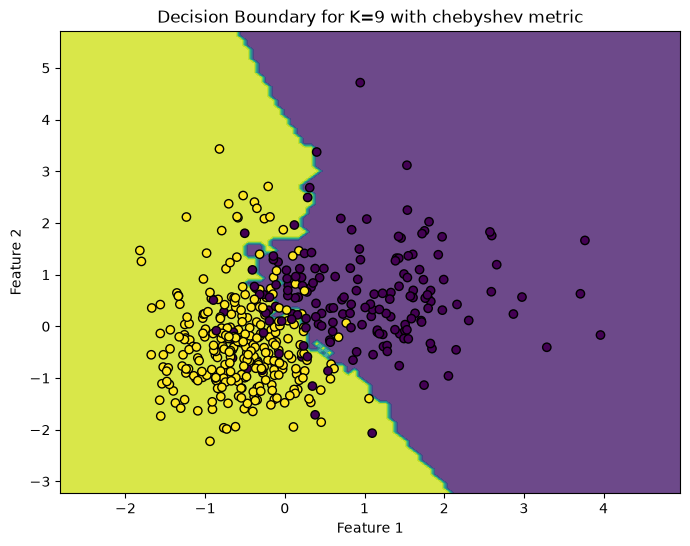

In [19]:
plot_decision_boundary(X_train_scaled, y_train, 5, 'euclidean')